In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('../PS3/02_Datasets/SHM')
TRAIN_DIR = DATA_DIR / 'Train'
LABEL_PATH = DATA_DIR / 'Train_Labels.csv'
TRAIN_FILES = sorted(TRAIN_DIR.glob('train*.csv'))
OUTPUT_PATH = Path('shm_engineered_features.csv')
print('Files:', len(TRAIN_FILES))

Files: 64


In [2]:
def load_signal(path):
    return pd.read_csv(path, usecols=[0]).iloc[:, 0].to_numpy(dtype=np.float64)

def safe_quantile(x, q):
    return float(np.quantile(x, q))

def zero_crossing_rate(x):
    centred = x - np.mean(x)
    return float(np.mean(centred[:-1] * centred[1:] < 0))

def spectral_features(x):
    # Use a bounded sample for FFT so memory and runtime stay predictable.
    max_points = 200000
    if len(x) > max_points:
        idx = np.linspace(0, len(x)-1, max_points).astype(int)
        x = x[idx]
    x = x - np.mean(x)
    power = np.abs(np.fft.rfft(x)) ** 2
    if len(power) <= 1 or power.sum() == 0:
        return {'fft_dominant_bin': 0.0, 'fft_spectral_centroid': 0.0, 'fft_low_power_ratio': 0.0, 'fft_high_power_ratio': 0.0}
    freq = np.fft.rfftfreq(len(x), d=1.0)
    power[0] = 0.0
    total = power.sum()
    split = max(1, len(power)//4)
    return {'fft_dominant_bin': float(np.argmax(power)), 'fft_spectral_centroid': float((freq*power).sum()/total), 'fft_low_power_ratio': float(power[:split].sum()/total), 'fft_high_power_ratio': float(power[-split:].sum()/total)}


In [3]:
def extract_features(x, filename):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) == 0: raise ValueError(f'No valid samples in {filename}')
    mean = np.mean(x)
    std = np.std(x)
    abs_x = np.abs(x)
    rms = np.sqrt(np.mean(x*x))
    diff = np.diff(x)
    features = {
        'filename': filename, 'n_samples': len(x),
        'mean': mean, 'std': std, 'min': np.min(x), 'max': np.max(x), 'range': np.ptp(x),
        'median': np.median(x), 'q01': safe_quantile(x,.01), 'q05': safe_quantile(x,.05),
        'q25': safe_quantile(x,.25), 'q75': safe_quantile(x,.75), 'q95': safe_quantile(x,.95), 'q99': safe_quantile(x,.99),
        'iqr': safe_quantile(x,.75)-safe_quantile(x,.25), 'abs_mean': np.mean(abs_x),
        'rms': rms, 'energy_per_sample': np.mean(x*x),
        'crest_factor': np.max(abs_x)/(rms + 1e-12), 'zero_crossing_rate': zero_crossing_rate(x),
        'diff_mean': np.mean(diff), 'diff_std': np.std(diff), 'diff_abs_mean': np.mean(np.abs(diff)),
        'diff_max_abs': np.max(np.abs(diff)),
    }
    features.update(spectral_features(x))
    return features

rows = []
for i, path in enumerate(TRAIN_FILES, 1):
    rows.append(extract_features(load_signal(path), path.name))
    if i % 10 == 0: print(f'Processed {i}/{len(TRAIN_FILES)}')
feature_table = pd.DataFrame(rows)
display(feature_table.head())
print('Feature shape:', feature_table.shape)

Processed 10/64
Processed 20/64
Processed 30/64
Processed 40/64
Processed 50/64
Processed 60/64


,filename,n_samples,mean,std,min,max,range,median,q01,q05,...,crest_factor,zero_crossing_rate,diff_mean,diff_std,diff_abs_mean,diff_max_abs,fft_dominant_bin,fft_spectral_centroid,fft_low_power_ratio,fft_high_power_ratio
0,train01.csv,581119,5.935087,8.631424,-19.343730,39.391250,58.734980,5.877941,-15.473143,-10.280573,...,3.760482,0.040011,1.710272e-05,0.841824,0.655596,7.771517,6.0,0.002148,0.994855,0.001023
1,train02.csv,581119,-7.732042,10.753985,-37.650806,25.297182,62.947988,-8.015717,-29.840237,-27.880156,...,2.842622,0.033269,-2.043525e-05,0.524750,0.391346,15.854985,6.0,0.000945,0.997883,0.000349
2,train03.csv,581119,1.926789,9.019788,-28.079456,29.944937,58.024393,1.963803,-22.896507,-14.864844,...,3.246665,0.084045,3.343685e-06,0.669238,0.520277,7.160041,5.0,0.001741,0.995531,0.000809
3,train04.csv,581119,-2.477910,6.969857,-54.097850,38.489470,92.587320,-2.595728,-18.591022,-14.313705,...,7.313263,0.042286,-6.189841e-06,0.835037,0.648803,14.698496,6.0,0.006917,0.986333,0.001518
4,train05.csv,581119,3.074603,8.830389,-19.364319,29.429405,48.793724,2.978921,-15.563205,-13.177941,...,3.147414,0.033232,-3.731464e-07,0.476161,0.369375,7.802064,5.0,0.000807,0.998106,0.000395


Feature shape: (64, 28)


In [4]:
labels = pd.read_csv(LABEL_PATH)
labels['damage'] = pd.to_numeric(labels['damage'], errors='coerce')
dataset = feature_table.merge(labels[['filename','damage']], on='filename', how='left', validate='one_to_one')
if dataset['damage'].isna().any(): raise ValueError('Missing label after feature/label join.')
numeric = dataset.select_dtypes(include='number')
quality = pd.DataFrame({'missing':numeric.isna().sum(), 'infinite':np.isinf(numeric.to_numpy()).sum(axis=0), 'n_unique':numeric.nunique()})
display(quality)
if quality[['missing','infinite']].to_numpy().sum() > 0: raise ValueError('Invalid feature values found.')
display(dataset.corr(numeric_only=True)['damage'].sort_values().to_frame('corr_with_damage').tail(12))

,missing,infinite,n_unique
n_samples,0,0,1
mean,0,0,64
std,0,0,64
min,0,0,64
max,0,0,64
range,0,0,64
median,0,0,63
q01,0,0,64
q05,0,0,64
q25,0,0,64


,corr_with_damage
q95,0.470707
q99,0.541022
diff_max_abs,0.554968
max,0.582831
abs_mean,0.689651
rms,0.696631
std,0.700776
energy_per_sample,0.709391
iqr,0.744425
range,0.916794


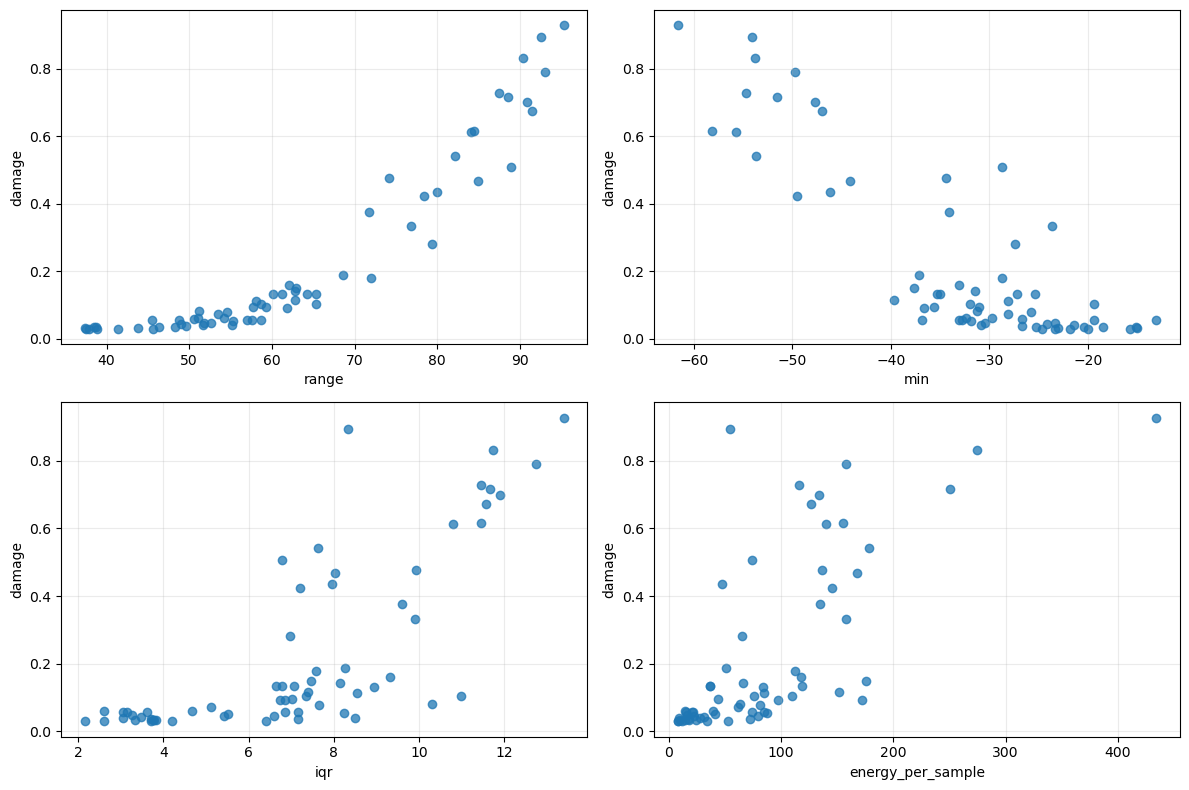

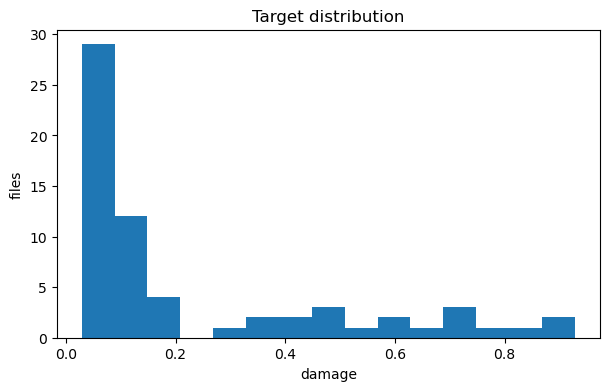

In [5]:
top = dataset.corr(numeric_only=True)['damage'].abs().sort_values(ascending=False).index[1:5]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), top):
    ax.scatter(dataset[col], dataset['damage'], alpha=.75)
    ax.set_xlabel(col); ax.set_ylabel('damage'); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4)); plt.hist(dataset['damage'], bins=15); plt.xlabel('damage'); plt.ylabel('files'); plt.title('Target distribution'); plt.show()

In [6]:
dataset.to_csv(OUTPUT_PATH, index=False)
print('Saved:', OUTPUT_PATH.resolve())
print('Rows:', len(dataset), 'Features excluding filename/damage:', len(dataset.columns)-2)

Saved: C:\Users\limju\Documents\AY2627\Semester 1\Hackathon\shm_engineered_features.csv
Rows: 64 Features excluding filename/damage: 27
